# Nationality pairs that played together
Find the top 2 nationality pairs (using `country_of_birth`) among teammate pairs.
Rows with missing `country_of_birth` are excluded.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '../Data'  # change to ../PreProcessdData if needed
teammates_df = pd.read_csv(f'{DATA_DIR}/player_teammates_played_with/player_teammates_played_with.csv')
profiles_df = pd.read_csv(f'{DATA_DIR}/player_profiles/player_profiles.csv')

print('teammates_df columns:', teammates_df.columns.tolist())
print('profiles_df columns:', profiles_df.columns.tolist())
display(teammates_df.head())
display(profiles_df.head())

teammates_df columns: ['player_id', 'teammate_player_id', 'teammate_player_name', 'ppg_played_with', 'joint_goal_participation', 'minutes_played_with']
profiles_df columns: ['player_id', 'player_slug', 'player_name', 'player_image_url', 'name_in_home_country', 'date_of_birth', 'place_of_birth', 'country_of_birth', 'height', 'citizenship', 'is_eu', 'position', 'main_position', 'foot', 'current_club_id', 'current_club_name', 'joined', 'contract_expires', 'outfitter', 'social_media_url', 'player_agent_id', 'player_agent_name', 'contract_option', 'date_of_last_contract_extension', 'on_loan_from_club_id', 'on_loan_from_club_name', 'contract_there_expires', 'second_club_url', 'second_club_name', 'third_club_url', 'third_club_name', 'fourth_club_url', 'fourth_club_name', 'date_of_death']


C:\Users\User\AppData\Local\Temp\ipykernel_26320\1389229963.py:7: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles_df = pd.read_csv(f'{DATA_DIR}/player_profiles/player_profiles.csv')


,player_id,teammate_player_id,teammate_player_name,ppg_played_with,joint_goal_participation,minutes_played_with
0,100001,116163,Leonardo Jara,1.69,2.0,NaN
1,100001,184672,Guido Carrillo,1.74,4.0,NaN
2,100001,222052,Gastón Gil Romero,1.64,1.0,NaN
3,100001,117874,Rafael Pérez,1.65,NaN,NaN
4,100001,533568,Nahuel Tenaglia,1.77,1.0,NaN


,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Filter valid player nationalities
Use `country_of_birth` as nationality and drop missing values.

In [15]:
def find_column(columns, candidates):
    for name in candidates:
        if name in columns:
            return name
    return None

player_id_col = find_column(profiles_df.columns, ['player_id', 'id'])
country_col = find_column(profiles_df.columns, ['country_of_birth'])
if player_id_col is None or country_col is None:
    raise ValueError('Expected columns not found in player_profiles.')

profiles_clean = profiles_df[[player_id_col, country_col]].dropna()
profiles_clean[country_col] = profiles_clean[country_col].astype(str).str.strip()
profiles_clean = profiles_clean[profiles_clean[country_col] != '']
print('Profiles with nationality:', len(profiles_clean))
display(profiles_clean.head())

Profiles with nationality: 76026


,player_id,country_of_birth
0,1,Germany
1,100011,Brazil
2,10,Germany
3,10001,Ireland
4,100001,Argentina


## Join teammates with player nationalities
Map each player and teammate to nationality and remove missing pairs.

In [16]:
p1_col = find_column(teammates_df.columns, ['player_id', 'player_id_1', 'playerId'])
p2_col = find_column(teammates_df.columns, ['teammate_id', 'teammate_player_id', 'player_id_2', 'teammateId'])
if p1_col is None or p2_col is None:
    raise ValueError('Expected player/teammate id columns not found in player_teammates_played_with.')

pairs = teammates_df[[p1_col, p2_col]].dropna().copy()
nat_map = profiles_clean.set_index(player_id_col)[country_col]
pairs['nat1'] = pairs[p1_col].map(nat_map)
pairs['nat2'] = pairs[p2_col].map(nat_map)
pairs = pairs.dropna(subset=['nat1', 'nat2'])
print('Valid nationality pairs:', len(pairs))
display(pairs.head())

Valid nationality pairs: 678204


,player_id,teammate_player_id,nat1,nat2
0,100001,116163,Argentina,Argentina
1,100001,184672,Argentina,Argentina
3,100001,117874,Argentina,Colombia
4,100001,533568,Argentina,Argentina
5,100001,508134,Argentina,Argentina


## Count nationality pair co-occurrences and find top 2
Create unordered nationality pairs and select the top 2.

In [17]:
nat_a = pairs['nat1'].astype(str)
nat_b = pairs['nat2'].astype(str)
pair_left = np.where(nat_a <= nat_b, nat_a, nat_b)
pair_right = np.where(nat_a <= nat_b, nat_b, nat_a)
pairs['pair'] = pair_left + ' | ' + pair_right

pair_counts = pairs['pair'].value_counts().reset_index()
pair_counts.columns = ['pair', 'count']
top2 = pair_counts.head(2)
display(top2)

,pair,count
0,Italy | Italy,75757
1,Spain | Spain,46269


## Display results
Table and bar chart for the top 2 nationality pairs.

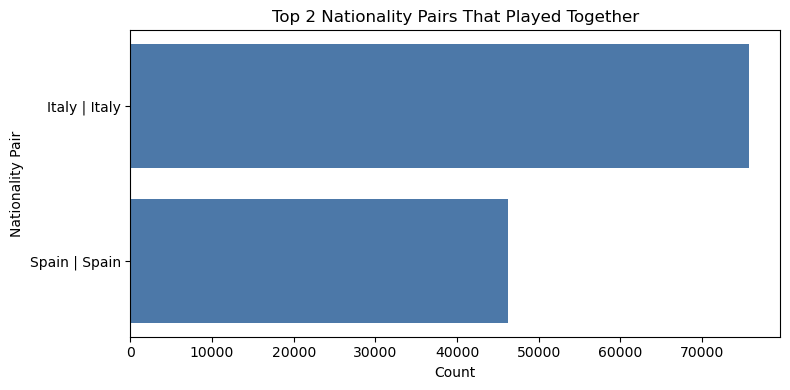

In [18]:
if top2.empty:
    print('No results to display.')
else:
    plt.figure(figsize=(8, 4))
    plt.barh(top2['pair'], top2['count'], color='#4C78A8')
    plt.title('Top 2 Nationality Pairs That Played Together')
    plt.xlabel('Count')
    plt.ylabel('Nationality Pair')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Heatmap of nationality co-occurrence
Heatmap showing how often each nationality pair played together.

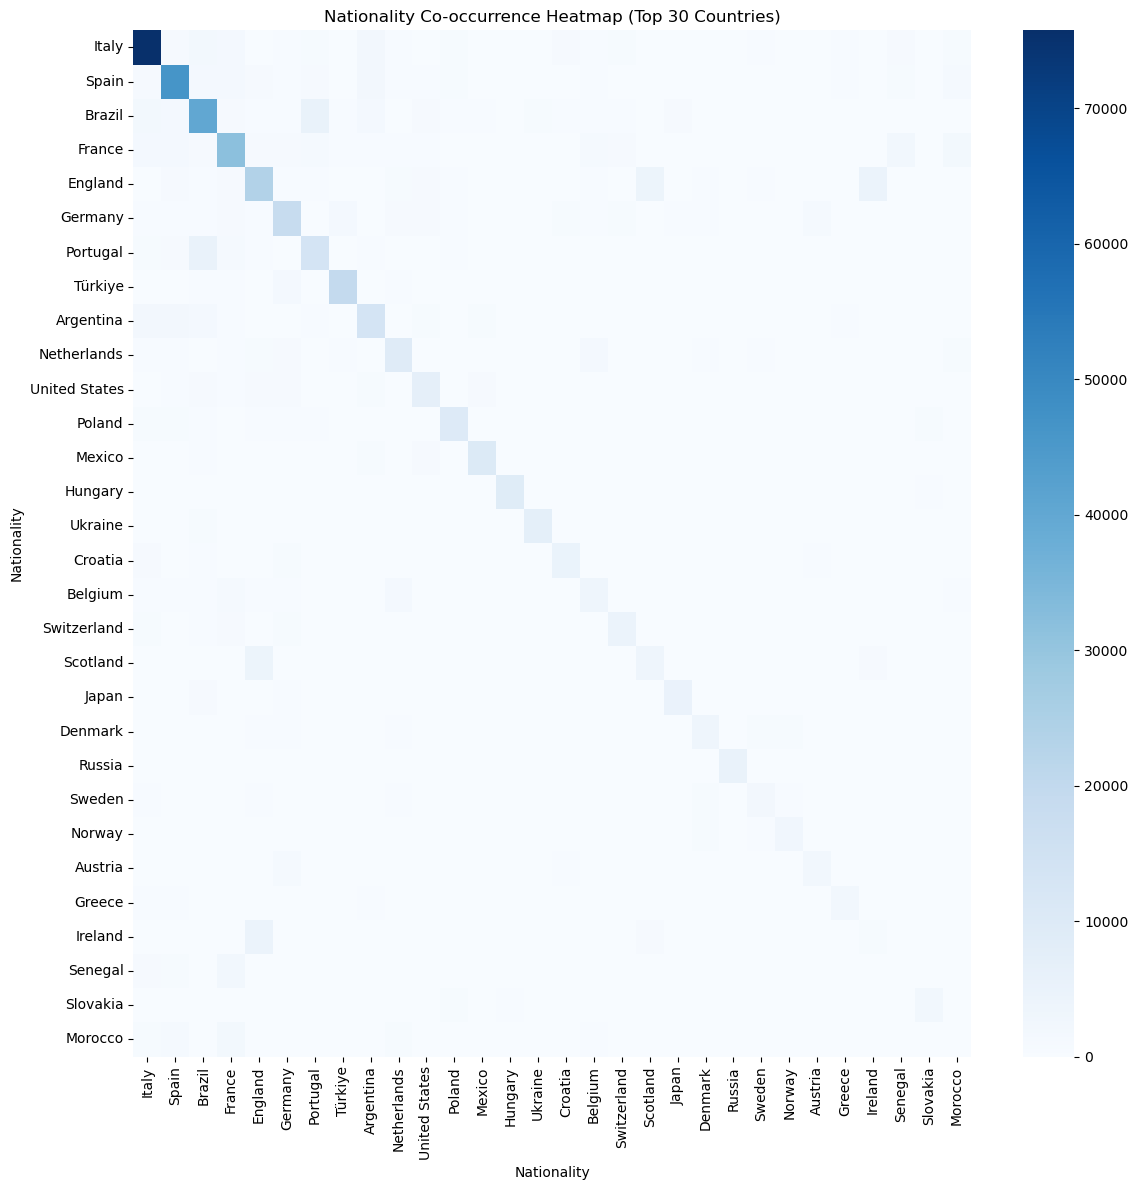

In [19]:
import seaborn as sns

pairs_clean = pairs.copy()
left = np.where(pairs_clean['nat1'] <= pairs_clean['nat2'], pairs_clean['nat1'], pairs_clean['nat2'])
right = np.where(pairs_clean['nat1'] <= pairs_clean['nat2'], pairs_clean['nat2'], pairs_clean['nat1'])
pairs_clean['left'] = left
pairs_clean['right'] = right

country_counts = pd.concat([pairs_clean['left'], pairs_clean['right']]).value_counts()
top_countries = country_counts.head(30).index.tolist()

filtered = pairs_clean[
    pairs_clean['left'].isin(top_countries) | pairs_clean['right'].isin(top_countries)
].copy()

ct = pd.crosstab(filtered['left'], filtered['right'])
heat = ct.add(ct.T, fill_value=0)

# Keep diagonal counts as-is (same nationality pairs).
for idx in heat.index:
    if idx in ct.index and idx in ct.columns:
        heat.loc[idx, idx] = ct.loc[idx, idx]

# Ensure a full 30x30 grid in the same order.
heat = heat.reindex(index=top_countries, columns=top_countries, fill_value=0)

if heat.empty:
    print('No data to plot for heatmap.')
else:
    fig_w = max(10, min(30, heat.shape[1] * 0.4))
    fig_h = max(8, min(30, heat.shape[0] * 0.4))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(heat, cmap='Blues')
    plt.title('Nationality Co-occurrence Heatmap (Top 30 Countries)')
    plt.xlabel('Nationality')
    plt.ylabel('Nationality')
    plt.tight_layout()
    plt.show()

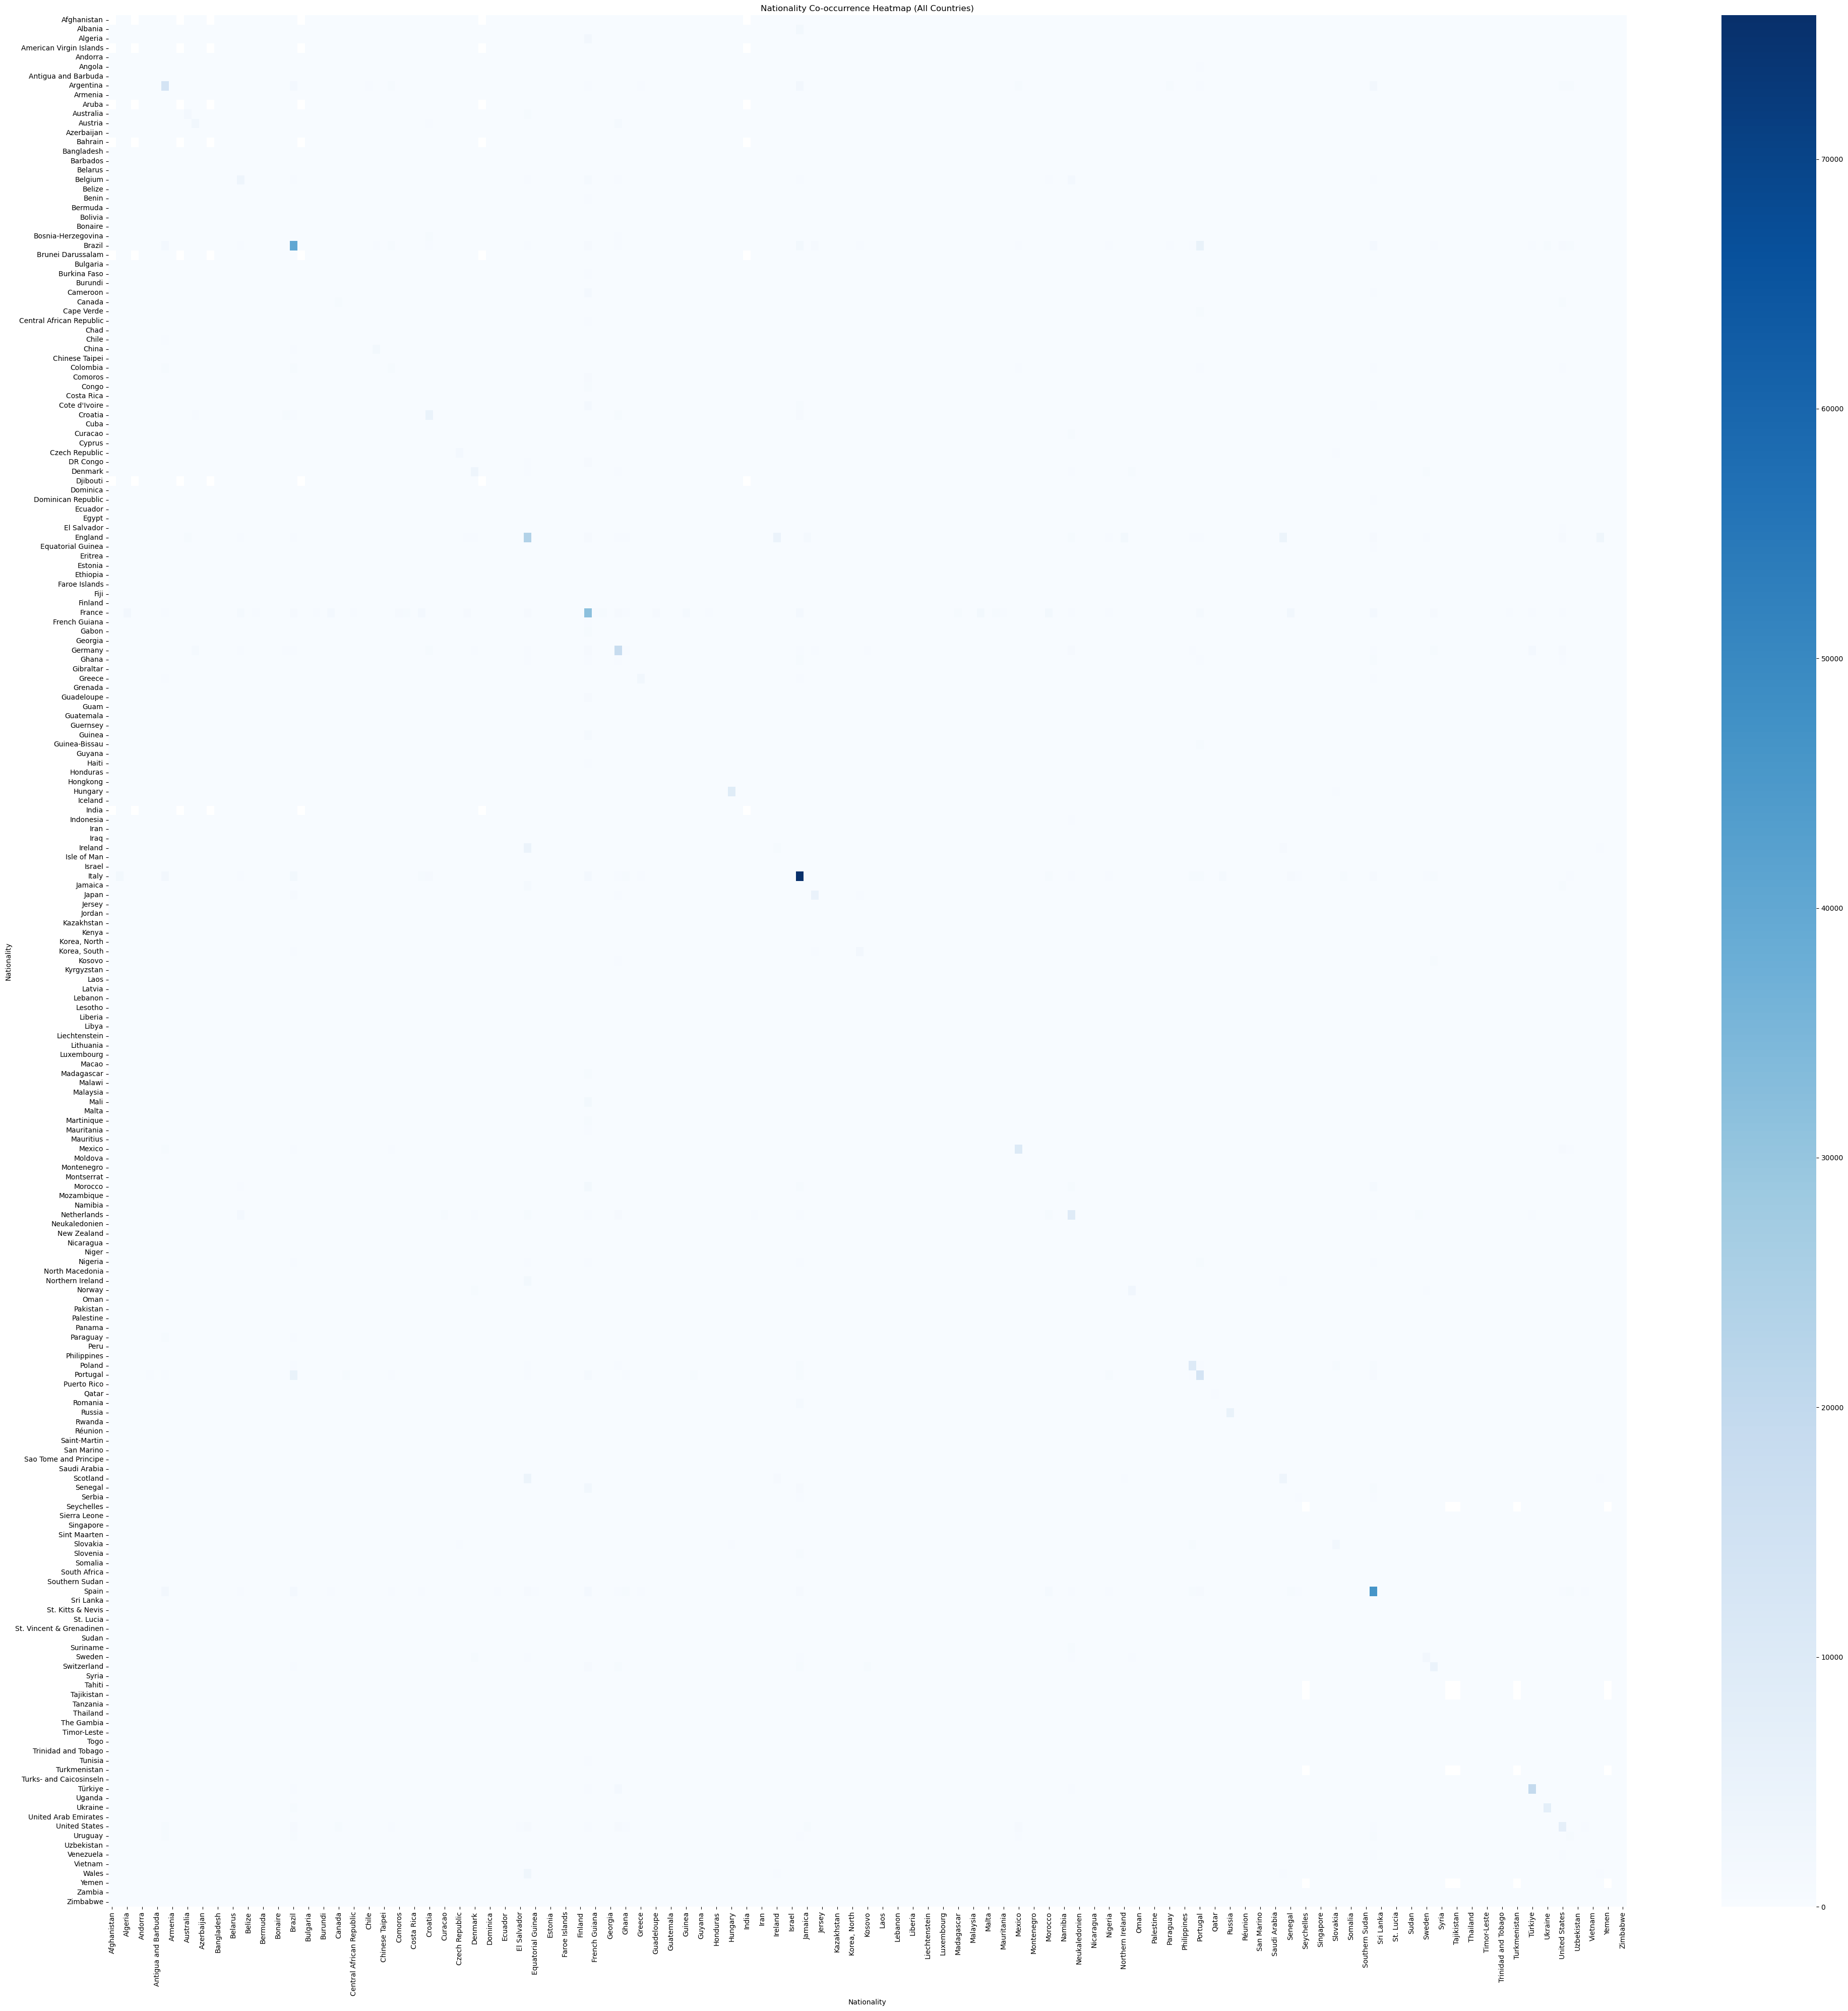

In [20]:
# Extra figure: full nationality heatmap (all countries).
ct_all = pd.crosstab(pairs_clean['left'], pairs_clean['right'])
heat_all = ct_all.add(ct_all.T, fill_value=0)
for idx in heat_all.index:
    if idx in ct_all.index and idx in ct_all.columns:
        heat_all.loc[idx, idx] = ct_all.loc[idx, idx]

if heat_all.empty:
    print('No data to plot for full heatmap.')
else:
    fig_w = max(12, min(40, heat_all.shape[1] * 0.3))
    fig_h = max(10, min(40, heat_all.shape[0] * 0.3))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(heat_all, cmap='Blues')
    plt.title('Nationality Co-occurrence Heatmap (All Countries)')
    plt.xlabel('Nationality')
    plt.ylabel('Nationality')
    plt.tight_layout()
    plt.show()

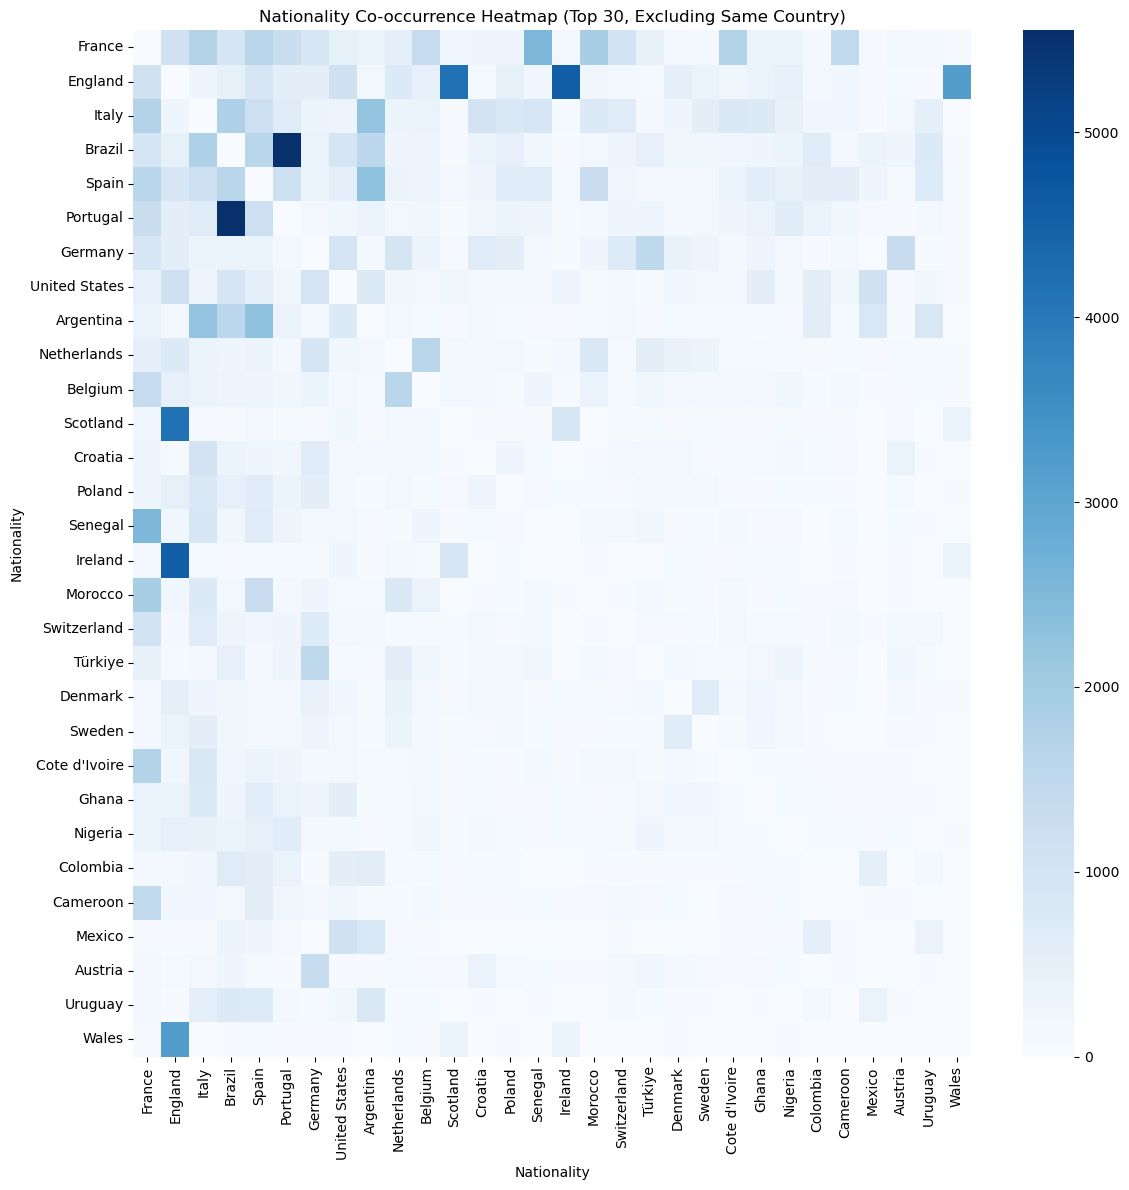

In [21]:
# Extra figure: top 30 countries excluding same-country pairs.
offdiag = pairs_clean[pairs_clean['left'] != pairs_clean['right']].copy()
if offdiag.empty:
    print('No cross-country pairs to plot.')
else:
    off_counts = pd.concat([offdiag['left'], offdiag['right']]).value_counts()
    top30_cross = off_counts.head(30).index.tolist()
    off_filtered = offdiag[offdiag['left'].isin(top30_cross) | offdiag['right'].isin(top30_cross)]
    ct_off = pd.crosstab(off_filtered['left'], off_filtered['right'])
    heat_off = ct_off.add(ct_off.T, fill_value=0)
    heat_off = heat_off.reindex(index=top30_cross, columns=top30_cross, fill_value=0)
    for idx in heat_off.index:
        heat_off.loc[idx, idx] = 0
    fig_w = max(10, min(30, heat_off.shape[1] * 0.4))
    fig_h = max(8, min(30, heat_off.shape[0] * 0.4))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(heat_off, cmap='Blues')
    plt.title('Nationality Co-occurrence Heatmap (Top 30, Excluding Same Country)')
    plt.xlabel('Nationality')
    plt.ylabel('Nationality')
    plt.tight_layout()
    plt.show()